# Model predictions against the surveys the models never saw

The 2026-08 refresh added surveys the fitted panels do not contain. They are the only rows in this
project that test the models rather than describe their fit, so they get their own notebook.

**Two levels of "unseen", and they answer different questions.**

- **Held out** — the *country-year* is absent from the fitted panel. 17 surveys. The model may
  still have seen an earlier survey from the same country, so it knows roughly where that country
  sits; what it is being asked for is the movement since.
- **New country** — the *country* is absent from the panel entirely. 4 of the 17 (Mozambique,
  Nauru, Qatar, Vanuatu). This is the harder test, and with n = 4 it is an illustration, not a
  statistic — no correlation computed on four points means anything.

**One caveat applies to every number here and is not correctable:** the surveys measure ages
**15–49**; the models are fitted and predicted on **18+**. Part of every gap below is that
mismatch rather than model error.

Tables come from `src/14_coherent_ggi_comparison.py`. The GGI definitions are compared against
these same surveys in section G of `09_01_coherent_ggi_comparison.ipynb`; here the subject is the
**outcomes** — the predicted adoption levels and the ratio between them.

In [1]:
import _bootstrap  # noqa: F401  — puts src/ on sys.path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import params

warnings.filterwarnings('ignore')

STYLE = params.STYLE
PALETTE = STYLE['colors']
INK, MUTED, GRID = '#222222', '#666666', '#d9d9d9'
FIGDIR = params.FIG / 'unseen_surveys'
FIGDIR.mkdir(parents=True, exist_ok=True)


def latest(stem):
    """most recent date-stamped build from src/14_coherent_ggi_comparison.py"""
    matches = sorted(f for f in (params.OUTPUTS / 'tables').glob(f'ggi_comparison_{stem}_*.csv')
                     if re.fullmatch(rf'ggi_comparison_{stem}_\d{{8}}\.csv', f.name))
    if not matches:
        raise FileNotFoundError(f'no ggi_comparison_{stem}_<date>.csv — '
                                'run src/14_coherent_ggi_comparison.py')
    return pd.read_csv(matches[-1])


unseen       = latest('unseen_surveys')
levels       = latest('groundtruth_levels')
level_stats  = latest('groundtruth_level_stats')
gt           = latest('groundtruth')
gt_stats     = latest('groundtruth_stats')

INDICATORS = params.COHERENT_GGI['indicators']

# Observed and predicted are the two things being compared, so they take the first two hues of the
# project's categorical order (rebuilt for colour-vision accessibility in D23) and are backed by
# marker shape, so the pair survives a greyscale print.
OBS_COLOUR, PRED_COLOUR = PALETTE[0], PALETTE[1]
OBS_MARKER, PRED_MARKER = 'o', 'D'
NEW_COUNTRY_INK = PALETTE[2]

# Which predicted gender gap the level figure shows in its third column. The point of that column
# is to put the ratio beside the two levels it is built from, so it carries ONE definition — the
# comparison between definitions belongs in 09_01 section G, not here.
#   'direct'          the GGI the model predicts directly
#   'coherent_parity' the ratio of the (parity-capped) predicted levels — the project's primary
#   'coherent_raw'    the same, uncapped
GGI_DEFINITION = 'direct'

GGI_LABEL = {'direct': 'directly predicted',
             'coherent_parity': 'coherent, parity-capped',
             'coherent_raw': 'coherent, raw'}[GGI_DEFINITION]

# Which accuracy metric the bar chart shows. MAE and R2 disagree on purpose: MAE is the average
# miss in the units of the outcome, R2 is whether the model beats predicting the sample mean.
# R2 here is against the 1:1 line, so it charges for bias and scale error and can go negative —
# `pearson_r` in the tables is the association alone and stays high even when predictions are
# systematically off. A sample can look good on one and poor on the other; that is the point.
METRIC = 'mae'

METRIC_SPEC = {
    'mae':  dict(label='Mean absolute error against the survey', higher_is_better=False, fmt='{:.3f}'),
    'rmse': dict(label='RMSE against the survey',                higher_is_better=False, fmt='{:.3f}'),
    'r2':   dict(label='R² against the 1:1 line',                higher_is_better=True,  fmt='{:.2f}'),
}[METRIC]


def tidy(ax, title=None, xlabel=None, ylabel=None):
    """the project's axis treatment: recessive frame, muted labels"""
    if title:
        ax.set_title(title, fontsize=STYLE['label_fs'], color=INK, fontweight='bold', loc='left')
    for which, lab in (('x', xlabel), ('y', ylabel)):
        if lab:
            getattr(ax, f'set_{which}label')(lab, fontsize=STYLE['tick_fs'], color=MUTED)
    ax.tick_params(labelsize=STYLE['tick_fs'], colors=MUTED, length=3)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    return ax


n_surveys = unseen[unseen['indicator'] == 'internet'].shape[0]
n_new = unseen[(unseen['indicator'] == 'internet') & (~unseen['country_in_training'])].shape[0]
print(f'{n_surveys} unseen surveys | {n_new} of them from countries never in the fitted panel')
print(unseen[unseen['indicator'] == 'internet']
      .groupby('survey_type')['gid_0'].count().to_dict())

17 unseen surveys | 4 of them from countries never in the fitted panel
{'continuous dhs8': 1, 'dhs8': 11, 'mics6': 5}


## 1. Which surveys

Sorted by year. `country_in_training` is the second, harder sense of unseen: `False` means the
model had never seen that country at all.

In [2]:
(unseen[unseen['indicator'] == 'internet']
 [['gid_0', 'country', 'region', 'year', 'survey_type', 'country_in_training']]
 .rename(columns={'country_in_training': 'country_seen_in_panel'})
 .reset_index(drop=True))

,gid_0,country,region,year,survey_type,country_seen_in_panel
0,LSO,Lesotho,Sub-Saharan Africa,2022,dhs8,True
1,MOZ,Mozambique,Sub-Saharan Africa,2022,dhs8,False
2,AGO,Angola,Sub-Saharan Africa,2023,dhs8,True
3,COD,DR Congo,Sub-Saharan Africa,2023,dhs8,True
4,JOR,Jordan,Middle East & North Africa,2023,dhs8,True
5,LAO,Laos,East Asia & Pacific,2023,mics6,True
6,MLI,Mali,Sub-Saharan Africa,2023,dhs8,True
7,NRU,Nauru,East Asia & Pacific,2023,mics6,False
8,QAT,Qatar,Middle East & North Africa,2023,mics6,False
9,SEN,Senegal,Sub-Saharan Africa,2023,continuous dhs8,True


## 2. Predicted against observed

One point per survey, against the 1:1 line. Points **above** the line are countries the model reads
as more connected — or less unequal — than the survey found.

The first two columns are the outcomes the models actually fit; the third is the ratio built from
them, so an error in either level propagates into it. The third column carries **one** definition of
the gender gap, set by `GGI_DEFINITION` in the setup cell (`'direct'` by default,
`'coherent_parity'` or `'coherent_raw'` to swap). Comparing the three against each other is
section G of `09_01`, not this figure.

Only the **four largest misses in each panel** are named — labelling all 17 makes the plot
unreadable and the small errors are not the interesting ones. Countries the model had never seen at
all are drawn in a separate colour.

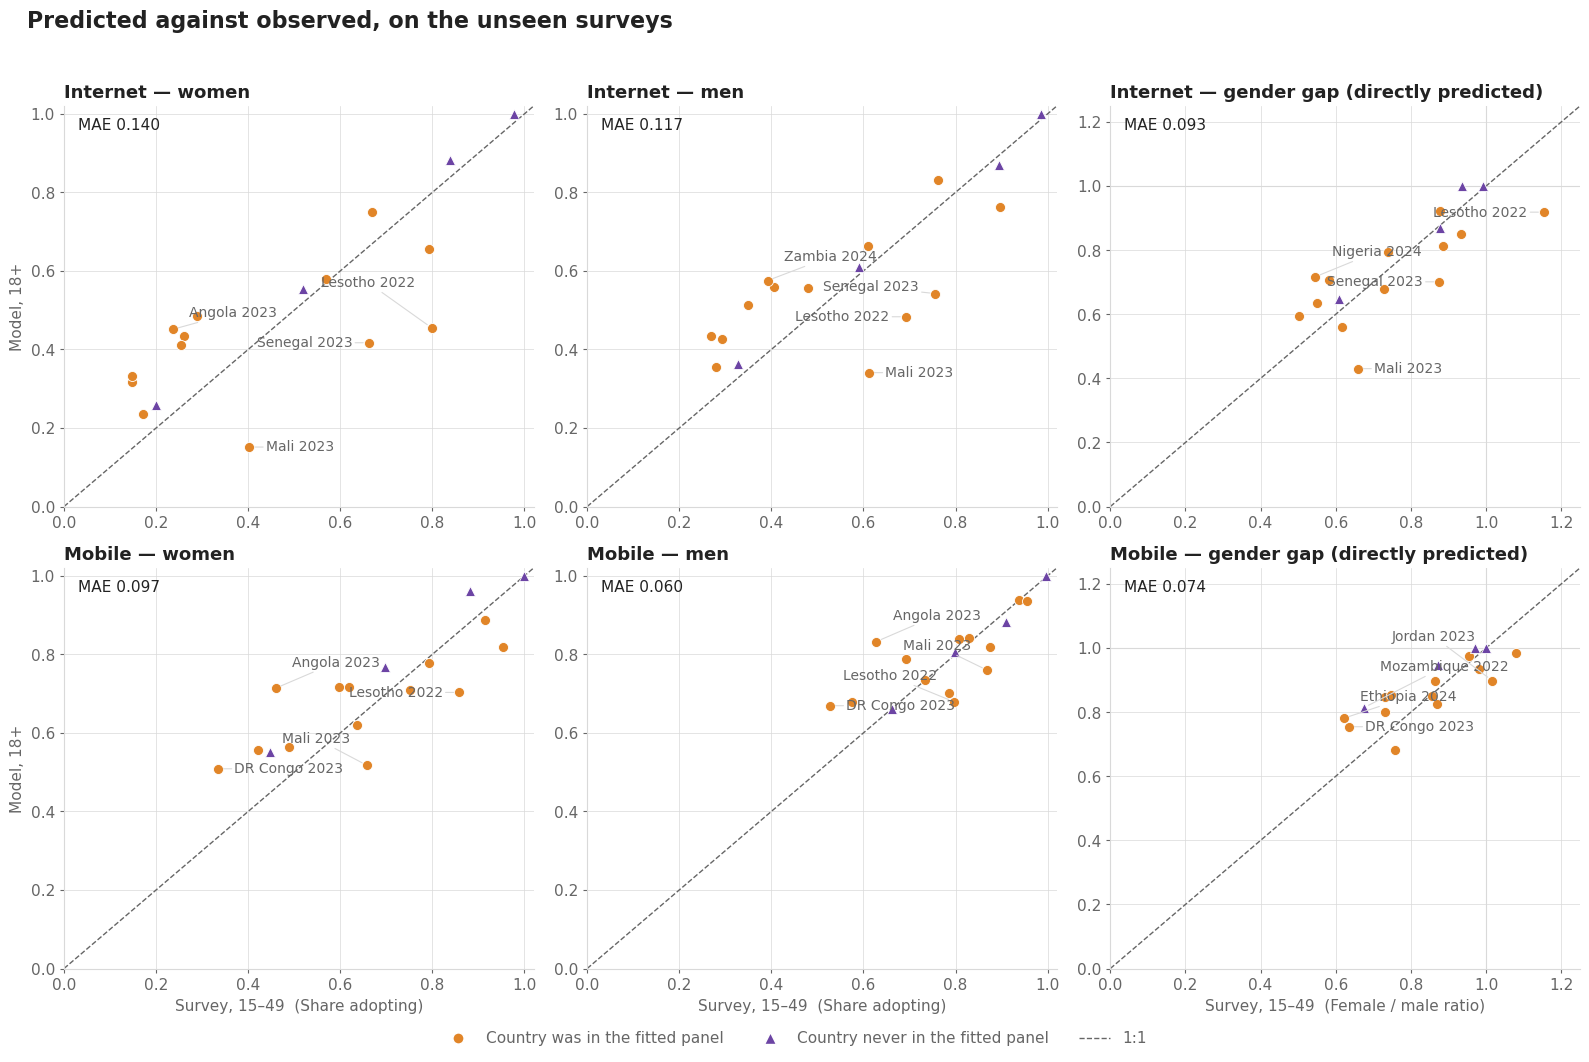

In [ ]:
N_LABEL = 4   # largest |error| named per panel

fig, axes = plt.subplots(2, 3, figsize=(16, 10.5))

PANELS = [('level_women', 'women', '', (0, 1.02)),
          ('level_men', 'men', '', (0, 1.02)),
          ('ggi', f'gender gap ({GGI_LABEL})', 'Female / male ratio', (0, 1.25))]

for row, indicator in enumerate(INDICATORS):
    block = unseen[unseen['indicator'] == indicator]
    for col, (key, title, lab, lim) in enumerate(PANELS):
        ax = axes[row, col]
        if key == 'ggi':
            obs, pred = block['observed'], block[f'predicted_{GGI_DEFINITION}']
            ax.axhline(1.0, color=GRID, linewidth=0.8, zorder=0)
            ax.axvline(1.0, color=GRID, linewidth=0.8, zorder=0)
        else:
            obs, pred = block[f'observed_{key}'], block[f'predicted_{key}']

        ax.plot(lim, lim, ls='--', color=MUTED, linewidth=1, zorder=1)
        for seen, colour, marker in ((True, PRED_COLOUR, 'o'), (False, NEW_COUNTRY_INK, '^')):
            m = (block['country_in_training'] == seen).to_numpy()
            ax.scatter(obs[m], pred[m], s=52, marker=marker, color=colour,
                       edgecolor='white', linewidth=0.6, zorder=3)

        # Name only the biggest misses. Labels are placed beside the point, then pushed apart
        # vertically until none overlap, with a hairline back to the point they belong to —
        # a fixed offset put them on top of each other and on top of other points.
        err = (pred - obs).abs()
        worst = list(err.nlargest(N_LABEL).index)
        span = lim[1] - lim[0]
        gap, dx = 0.075 * span, 0.035 * span
        placed = -np.inf
        for idx in sorted(worst, key=lambda j: pred[j]):
            ly = max(pred[idx], placed + gap)
            right = obs[idx] < lim[0] + 0.62 * span      # flip inwards near the right edge
            ax.annotate(f"{block.loc[idx, 'country']} {int(block.loc[idx, 'year'])}",
                        xy=(obs[idx], pred[idx]),
                        xytext=(obs[idx] + (dx if right else -dx), ly),
                        ha='left' if right else 'right', va='center',
                        fontsize=STYLE['tick_fs'] - 1, color=MUTED,
                        arrowprops=dict(arrowstyle='-', color=GRID, linewidth=0.8,
                                        shrinkA=0, shrinkB=4))
            placed = ly

        mae = err.mean()
        ax.text(0.03, 0.97, f'MAE {mae:.3f}', transform=ax.transAxes, va='top', ha='left',
                fontsize=STYLE['tick_fs'], color=INK)

        tidy(ax, title=f'{indicator.capitalize()} — {title}')
        ax.set_xlim(*lim); ax.set_ylim(*lim)
        ax.grid(color=GRID, linewidth=0.5)
        ax.set_axisbelow(True)
        if row == 1:
            ax.set_xlabel(f'Survey, 15–49  ({lab})', fontsize=STYLE['tick_fs'], color=MUTED)
        if col == 0:
            ax.set_ylabel('Model, 18+', fontsize=STYLE['tick_fs'], color=MUTED)

handles = [plt.Line2D([], [], marker='o', linestyle='None', markersize=8,
                      markerfacecolor=PRED_COLOUR, markeredgecolor='white',
                      label='Country was in the fitted panel'),
           plt.Line2D([], [], marker='^', linestyle='None', markersize=8,
                      markerfacecolor=NEW_COUNTRY_INK, markeredgecolor='white',
                      label='Country never in the fitted panel'),
           plt.Line2D([], [], ls='--', color=MUTED, linewidth=1, label='1:1')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Predicted against observed, on the unseen surveys',
             fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0.01, 1, 0.96))
if STYLE['save']:
    fig.savefig(FIGDIR / '1_unseen_scatter.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()


### Accuracy metrics

The three quantities in the figure above — the two adoption levels and the gender gap built from
them — scored against the survey. The GGI bar uses the same `GGI_DEFINITION` as the third column,
so the panel is internally consistent; all three definitions are compared in `09_01` section G.

`METRIC` in the setup cell switches the bar between `'mae'`, `'rmse'` and `'r2'`. They are not
interchangeable: MAE is the average miss in the outcome's own units, R² is whether the model beats
predicting the sample mean, measured against the 1:1 line so it charges for bias as well as
scatter. A sample can look strong on one and weak on the other — mobile's four new countries reach
`pearson_r` 0.99 and R² 0.50, which is exactly that gap.

`held_out` is the 17 unseen surveys; `held_out, new country` is the 4 whose country the models had
never seen. Four points is an illustration, not a statistic, so `n` is printed on every bar.


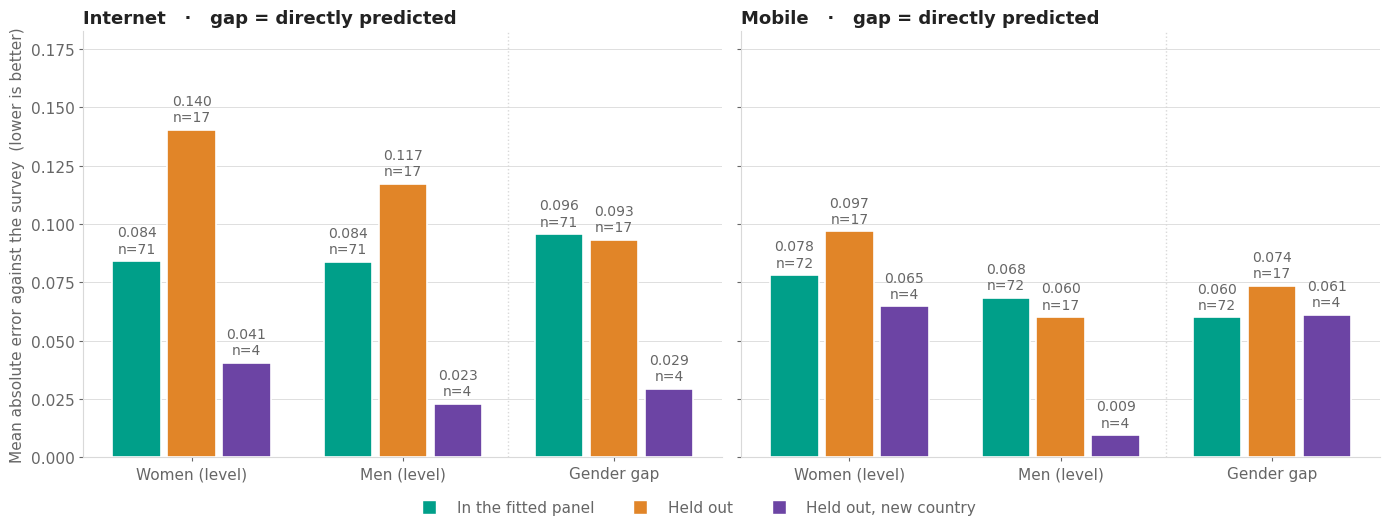

,indicator,sex,sample,n,bias,mae,rmse,r2,within_0.05,within_0.10,pearson_r,spearman_r
1,internet,men,in_training,71,0.0033,0.0838,0.1104,0.7758,36.6197,74.6479,0.8822,0.8801
2,internet,men,held_out,17,0.0172,0.1172,0.1396,0.6317,23.5294,47.0588,0.7983,0.7034
3,internet,men,held_out_new_country,4,0.0108,0.0229,0.0240,0.9914,100.0000,100.0000,0.9979,1.0000
5,internet,women,in_training,71,0.0082,0.0840,0.1098,0.8167,36.6197,64.7887,0.9051,0.9028
6,internet,women,held_out,17,0.0256,0.1404,0.1680,0.6144,23.5294,41.1765,0.7899,0.7892
7,internet,women,held_out_new_country,4,0.0406,0.0406,0.0426,0.9799,75.0000,100.0000,0.9997,1.0000
9,mobile,men,in_training,72,-0.0013,0.0684,0.0905,0.6347,43.0556,79.1667,0.7973,0.8095
10,mobile,men,held_out,17,0.0114,0.0600,0.0843,0.5865,52.9412,70.5882,0.7708,0.8039
11,mobile,men,held_out_new_country,4,-0.0042,0.0094,0.0137,0.9879,100.0000,100.0000,0.9946,1.0000
13,mobile,women,in_training,72,0.0024,0.0780,0.1007,0.7503,44.4444,70.8333,0.8667,0.8845


,indicator,definition,sample,n_dropped_zero_floor,n,bias,mae,rmse,r2,within_0.05,within_0.10,pearson_r,spearman_r
1,internet,coherent_parity,in_training,0,71,0.0153,0.1163,0.1511,0.6076,28.1690,53.5211,0.8036,0.8503
2,internet,coherent_parity,held_out,0,17,0.0446,0.1174,0.1439,0.3816,29.4118,47.0588,0.6659,0.8056
3,internet,coherent_parity,held_out_new_country,0,4,0.0529,0.0529,0.0641,0.8087,50.0000,75.0000,0.9886,0.9487
5,internet,coherent_raw,in_training,0,71,0.0159,0.1157,0.1507,0.6101,28.1690,54.9296,0.8057,0.8503
6,internet,coherent_raw,held_out,0,17,0.0454,0.1182,0.1442,0.3786,29.4118,47.0588,0.6656,0.8039
7,internet,coherent_raw,held_out_new_country,0,4,0.0560,0.0560,0.0674,0.7884,50.0000,75.0000,0.9818,0.8000
9,internet,direct,in_training,0,71,-0.0004,0.0956,0.1179,0.7614,29.5775,64.7887,0.8748,0.8651
10,internet,direct,held_out,0,17,-0.0135,0.0933,0.1153,0.6025,29.4118,70.5882,0.7825,0.7885
11,internet,direct,held_out_new_country,0,4,0.0248,0.0293,0.0371,0.9359,75.0000,100.0000,0.9821,0.9487
13,mobile,coherent_parity,in_training,0,72,0.0049,0.0579,0.0830,0.7214,61.1111,80.5556,0.8519,0.8589


In [4]:
SAMPLES = [('in_training', 'In the fitted panel'),
           ('held_out', 'Held out'),
           ('held_out_new_country', 'Held out, new country')]
SAMPLE_COLOUR = dict(zip([k for k, _ in SAMPLES], PALETTE[:3]))
SAMPLE_KEYS = [k for k, _ in SAMPLES]

# Levels and the gap in one frame: same metric, same samples, so they belong on one axis. The GGI
# rows are filtered to GGI_DEFINITION, matching the third column of the figure above.
metrics = pd.concat([
    (level_stats[level_stats['sample'].isin(SAMPLE_KEYS)]
     .assign(quantity=lambda d: d['sex'].str.capitalize() + ' (level)')),
    (gt_stats[(gt_stats['sample'].isin(SAMPLE_KEYS))
              & (gt_stats['definition'] == GGI_DEFINITION)]
     .assign(quantity='Gender gap')),
], ignore_index=True)

QUANTITIES = ['Women (level)', 'Men (level)', 'Gender gap']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True)

# The axes share y, so the limit has to come from BOTH panels: taking it per-panel let the second
# one win and clipped the tallest bar's label off the top.
vals_all = metrics[METRIC]
YMIN = min(0.0, vals_all.min() * 1.25)
YMAX = vals_all.max() * 1.30 if vals_all.max() > 0 else 0.05

for ax, indicator in zip(axes, INDICATORS):
    block = metrics[metrics['indicator'] == indicator]
    x = np.arange(len(QUANTITIES))
    width = 0.26

    for k, (key, label) in enumerate(SAMPLES):
        vals, ns = [], []
        for q in QUANTITIES:
            row = block[(block['quantity'] == q) & (block['sample'] == key)]
            vals.append(float(row[METRIC].squeeze()) if len(row) else np.nan)
            ns.append(int(row['n'].squeeze()) if len(row) else 0)
        pos = x + (k - 1) * width
        ax.bar(pos, vals, width * 0.88, color=SAMPLE_COLOUR[key],
               edgecolor='white', linewidth=1.2, zorder=3)
        for pp, v, n in zip(pos, vals, ns):
            # labels go above a positive bar and below a negative one (R2 can be < 0)
            above = v >= 0
            ax.annotate(METRIC_SPEC['fmt'].format(v) + f'\nn={n}', (pp, v),
                        textcoords='offset points', xytext=(0, 4 if above else -4),
                        ha='center', va='bottom' if above else 'top',
                        fontsize=STYLE['tick_fs'] - 1, color=MUTED)

    # the gap is a different kind of quantity from a level; mark the boundary rather than imply
    # the three bars are three of a kind
    ax.axvline(1.5, color=GRID, linewidth=1, linestyle=':', zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(QUANTITIES)
    ax.set_ylim(YMIN, YMAX)
    if YMIN < 0:
        ax.axhline(0, color=MUTED, linewidth=1, zorder=2)
    ax.grid(axis='y', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    tidy(ax, title=f'{indicator.capitalize()}   ·   gap = {GGI_LABEL}')

direction = 'higher is better' if METRIC_SPEC['higher_is_better'] else 'lower is better'
axes[0].set_ylabel(f"{METRIC_SPEC['label']}  ({direction})",
                   fontsize=STYLE['tick_fs'], color=MUTED)
handles = [plt.Line2D([], [], marker='s', linestyle='None', markersize=10,
                      markerfacecolor=SAMPLE_COLOUR[k], markeredgecolor='white', label=lab)
           for k, lab in SAMPLES]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.06))
#fig.suptitle('Accuracy on levels and on the gap, by sample', fontsize=STYLE['title_fs'],
#             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0, 1, 0.93))
if STYLE['save']:
    fig.savefig(FIGDIR / '2_accuracy_metrics.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()

display(level_stats[level_stats['sample'].isin(SAMPLE_KEYS)].round(4))
gt_stats[gt_stats['sample'].isin(SAMPLE_KEYS)].round(4)


## 3. The gender gap on the unseen surveys

The ratio of the two levels above, for every survey. Two model definitions against the one
observation — the directly predicted GGI and the project's primary coherent (parity-capped) one.
`09_01` section G takes the choice between definitions further.

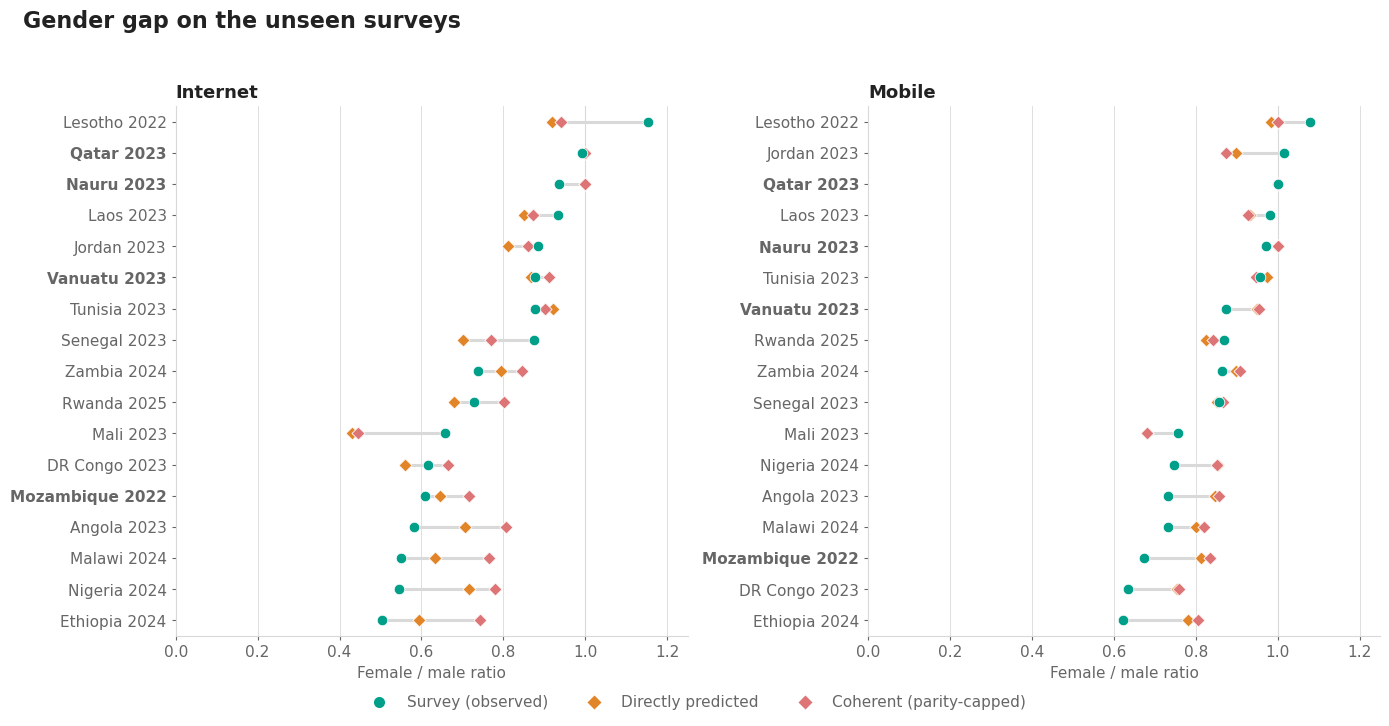

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

# Survey, direct and parity-capped coherent only. The raw coherent GGI is identical to the capped
# one except where it exceeds parity, so plotting it here adds a mark that is almost always hidden
# behind another; it is compared properly in 09_01 section G.
DEFS = [('direct', 'Directly predicted', PALETTE[1]),
        ('coherent_parity', 'Coherent (parity-capped)', PALETTE[3])]

for ax, indicator in zip(axes, INDICATORS):
    block = (unseen[unseen['indicator'] == indicator]
             .sort_values('observed', ascending=False).reset_index(drop=True))
    y = np.arange(len(block))

    lo = block[['observed'] + [f'predicted_{d}' for d, _, _ in DEFS]].min(axis=1)
    hi = block[['observed'] + [f'predicted_{d}' for d, _, _ in DEFS]].max(axis=1)
    ax.hlines(y, lo, hi, color=GRID, linewidth=2.2, zorder=1)

    for d, _, colour in DEFS:
        ax.scatter(block[f'predicted_{d}'], y, s=44, marker=PRED_MARKER, color=colour,
                   edgecolor='white', linewidth=0.6, zorder=3)
    ax.scatter(block['observed'], y, s=58, marker=OBS_MARKER, color=OBS_COLOUR,
               edgecolor='white', linewidth=0.6, zorder=4)
    ax.axvline(1.0, color=GRID, linewidth=0.8, zorder=0)

    ax.set_yticks(y)
    ax.set_yticklabels([f"{c} {int(yr)}" for c, yr in zip(block['country'], block['year'])])
    for tick, seen in zip(ax.get_yticklabels(), block['country_in_training']):
        if not seen:
            tick.set_color(NEW_COUNTRY_INK)
            tick.set_fontweight('bold')
    ax.set_ylim(len(block) - 0.5, -0.5)
    ax.grid(axis='x', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    tidy(ax, title=indicator.capitalize(), xlabel='Female / male ratio')
    ax.set_xlim(0, 1.25)

handles = ([plt.Line2D([], [], marker=OBS_MARKER, linestyle='None', markersize=9,
                       markerfacecolor=OBS_COLOUR, markeredgecolor='white',
                       label='Survey (observed)')]
           + [plt.Line2D([], [], marker=PRED_MARKER, linestyle='None', markersize=8,
                         markerfacecolor=c, markeredgecolor='white', label=lab)
              for _, lab, c in DEFS])
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Gender gap on the unseen surveys', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0, 1, 0.95))
if STYLE['save']:
    fig.savefig(FIGDIR / '3_unseen_ggi.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()

## 4. Signed error, worst first

Positive means the model sits **above** the survey. The direction matters more than the magnitude
here: a systematic sign is a bias the models could be corrected for, scatter around zero is not.

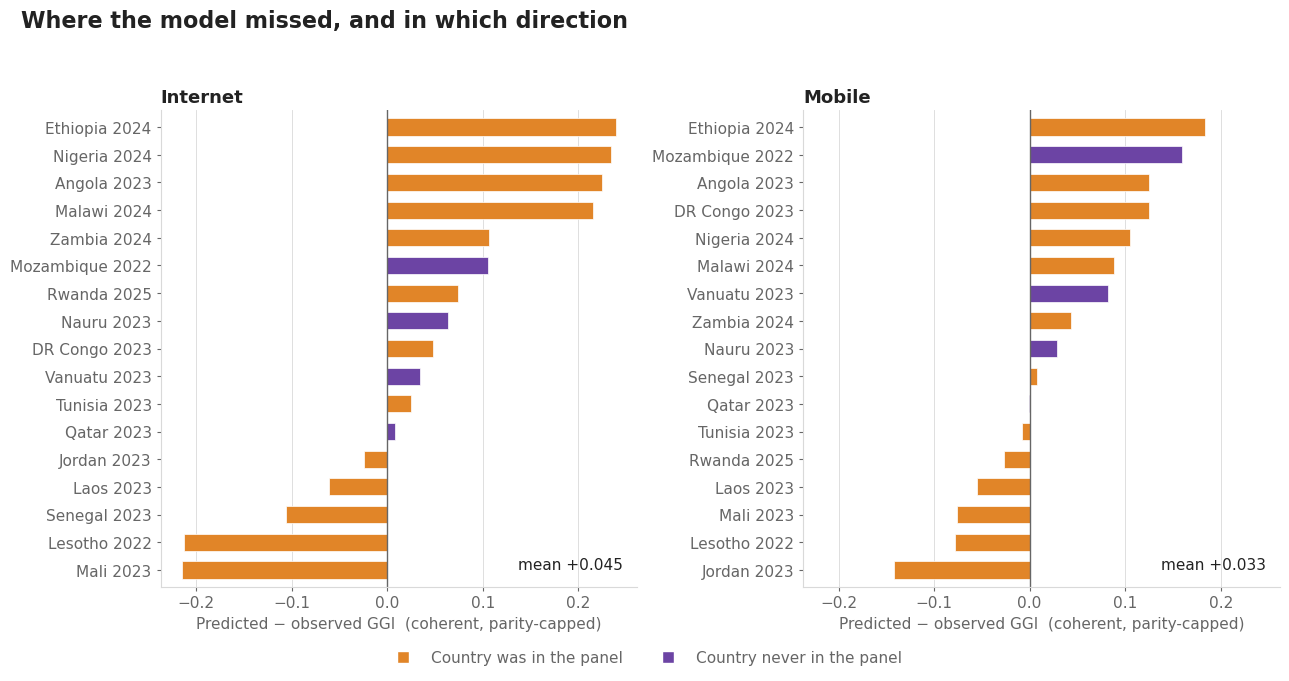

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True)

for ax, indicator in zip(axes, INDICATORS):
    block = (unseen[unseen['indicator'] == indicator]
             .assign(err=lambda d: d['error_coherent_parity'])
             .sort_values('err').reset_index(drop=True))
    y = np.arange(len(block))
    colours = [PRED_COLOUR if seen else NEW_COUNTRY_INK
               for seen in block['country_in_training']]
    ax.barh(y, block['err'], height=0.62, color=colours, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color=MUTED, linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels([f"{c} {int(yr)}" for c, yr in zip(block['country'], block['year'])])
    ax.set_ylim(-0.6, len(block) - 0.4)
    ax.grid(axis='x', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    bias = block['err'].mean()
    ax.text(0.97, 0.03, f'mean {bias:+.3f}', transform=ax.transAxes, ha='right', va='bottom',
            fontsize=STYLE['tick_fs'], color=INK)
    tidy(ax, title=indicator.capitalize(),
         xlabel='Predicted − observed GGI  (coherent, parity-capped)')

handles = [plt.Line2D([], [], marker='s', linestyle='None', markersize=9, markerfacecolor=c,
                      markeredgecolor='white', label=lab)
           for c, lab in ((PRED_COLOUR, 'Country was in the panel'),
                          (NEW_COUNTRY_INK, 'Country never in the panel'))]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Where the model missed, and in which direction', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0, 1, 0.94))
if STYLE['save']:
    fig.savefig(FIGDIR / '4_unseen_error.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()

## 5. Survey by survey

Everything above in one sheet, for reading individual cases.

In [7]:
cols = ['indicator', 'gid_0', 'country', 'year', 'survey_type', 'country_in_training',
        'observed_level_women', 'predicted_level_women',
        'observed_level_men', 'predicted_level_men',
        'observed', 'predicted_direct', 'predicted_coherent_raw', 'predicted_coherent_parity',
        'error_direct', 'error_coherent_raw', 'error_coherent_parity']
unseen[cols].round(4).reset_index(drop=True)

,indicator,gid_0,country,year,survey_type,country_in_training,observed_level_women,predicted_level_women,observed_level_men,predicted_level_men,observed,predicted_direct,predicted_coherent_raw,predicted_coherent_parity,error_direct,error_coherent_raw,error_coherent_parity
0,internet,LSO,Lesotho,2022,dhs8,True,0.7987,0.4549,0.6921,0.4833,1.1540,0.9187,0.9412,0.9412,-0.2353,-0.2128,-0.2128
1,internet,MOZ,Mozambique,2022,dhs8,False,0.2000,0.2591,0.3279,0.3620,0.6099,0.6465,0.7157,0.7157,0.0366,0.1058,0.1058
2,internet,AGO,Angola,2023,dhs8,True,0.2364,0.4513,0.4067,0.5598,0.5813,0.7056,0.8062,0.8062,0.1243,0.2249,0.2249
3,internet,COD,DR Congo,2023,dhs8,True,0.1725,0.2360,0.2799,0.3555,0.6163,0.5598,0.6638,0.6638,-0.0564,0.0476,0.0476
4,internet,JOR,Jordan,2023,dhs8,True,0.7926,0.6569,0.8961,0.7638,0.8846,0.8122,0.8601,0.8601,-0.0723,-0.0245,-0.0245
5,internet,LAO,Laos,2023,mics6,True,0.5698,0.5793,0.6100,0.6632,0.9342,0.8497,0.8736,0.8736,-0.0845,-0.0606,-0.0606
6,internet,MLI,Mali,2023,dhs8,True,0.4028,0.1516,0.6119,0.3410,0.6582,0.4304,0.4440,0.4440,-0.2278,-0.2142,-0.2142
7,internet,NRU,Nauru,2023,mics6,False,0.8380,0.8814,0.8947,0.8706,0.9366,1.0000,1.0125,1.0000,0.0634,0.0759,0.0634
8,internet,QAT,Qatar,2023,mics6,False,0.9770,1.0000,0.9850,1.0000,0.9919,1.0000,1.0000,1.0000,0.0081,0.0081,0.0081
9,internet,SEN,Senegal,2023,continuous dhs8,True,0.6620,0.4172,0.7561,0.5423,0.8756,0.7013,0.7692,0.7692,-0.1742,-0.1064,-0.1064


## Notes

- The models are **not refitted** for this notebook. `13_coherent_ggi.py` reads the published
  golden series from `dgg_pipeline`, so these are the predictions as shipped, scored against
  surveys that postdate them.
- `held_out` here means absent from the *fitted panel*, which is what
  `combined_multiple_years_no_missing_keep_countries_fb_aligned_itu_deleted.csv` contains. It is
  not a cross-validation split — see `11_fit_final_models.py` for the LOCO results.
- Age mismatch (15–49 survey vs 18+ prediction) is a floor on how well anything here can agree;
  it is not removable without a 15–49 prediction. See D33.